In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import umap
from sklearn.manifold import TSNE
from scipy.interpolate import interp1d
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [3]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

labels = (["Cotton"]*14 + ["Acrylic"]*18 + ["Nylon"]*18 + ["PP/PE"]*8 + ["Polyester"]*17 + ["Silk"]*11 + ["Wool"]*23)

ranges = [(24, 38), (50, 68), (70, 88), (88, 96), (96, 113), (125, 136), (137, 160)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums_labeled = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums_labeled.insert(loc = 2, column = "Labels", value = labels)
spectrums_labeled.iloc[:, :].head(20)


,Spectrum_ID,Subtype,Labels,4000.0,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,...,559.0,558.0,557.0,556.0,555.0,554.0,553.0,552.0,551.0,550.0
0,25,Cotton,Cotton,99.10,99.11,99.12,99.11,99.10,99.09,99.06,...,66.47,66.18,65.96,65.69,65.73,66.25,66.85,67.28,67.73,68.27
1,26,Cotton,Cotton,99.26,99.28,99.30,99.31,99.32,99.32,99.31,...,67.68,67.48,67.52,67.56,67.88,68.43,68.70,68.43,68.12,68.13
2,27,Cotton,Cotton,99.89,99.89,99.89,99.89,99.89,99.89,99.90,...,66.49,65.80,65.26,65.08,65.33,65.78,65.97,65.80,65.37,64.82
3,28,Cotton,Cotton,99.59,99.60,99.61,99.62,99.61,99.60,99.60,...,70.63,70.42,70.27,70.08,70.13,70.47,70.75,70.70,70.60,70.64
4,29,Cotton,Cotton,100.71,100.72,100.74,100.75,100.77,100.77,100.76,...,64.65,64.81,65.19,65.50,65.75,65.94,65.95,65.91,66.29,67.15
5,30,Cotton,Cotton,99.95,99.96,99.96,99.95,99.94,99.92,99.90,...,70.75,70.60,70.77,71.09,71.54,71.87,71.76,71.27,71.02,71.19
6,31,Cotton,Cotton,101.33,101.33,101.34,101.35,101.36,101.36,101.37,...,63.20,63.41,63.65,63.52,63.18,62.91,62.72,62.74,63.20,63.87
7,32,Cotton,Cotton,100.02,100.02,100.02,100.03,100.03,100.03,100.02,...,85.00,84.71,84.01,83.09,82.59,82.98,83.91,84.75,85.19,85.37
8,33,Cotton,Cotton,100.45,100.47,100.48,100.49,100.48,100.47,100.46,...,78.56,78.65,78.79,78.72,78.67,78.71,78.58,77.99,77.68,77.85
9,34,Cotton,Cotton,100.07,100.07,100.06,100.04,100.02,100.00,99.99,...,83.18,82.88,82.36,81.73,81.32,81.32,81.59,81.93,82.36,82.89


In [4]:
wn_common = np.arange(3999.0, 674.0, -1)

spectral_cols = [str(x) for x in wn_common]

def load_and_interpolate_csv(filepath):
    df = pd.read_csv(filepath, header=0, names=['wavenumber', 'intensity'])
    
    wn_src = df['wavenumber'].values
    ab_src = df['intensity'].values
    
    sort_idx = np.argsort(wn_src)
    wn_src = wn_src[sort_idx]
    ab_src = ab_src[sort_idx]
    
    f_interp = interp1d(wn_src, ab_src,
                        kind='cubic',
                        bounds_error=False,
                        fill_value=np.nan)
    
    interpolated = f_interp(wn_common)
    
    if np.any(np.isnan(interpolated)):
        nans = np.isnan(interpolated)
        interpolated[nans] = np.interp(
            np.where(nans)[0],
            np.where(~nans)[0],
            interpolated[~nans]
        )
    
    return interpolated


data_root = Path(".")

excluded = {"Lab_IR", "KARLILE_excel_27032019"}

rows = []

for folder in data_root.iterdir():
    if not folder.is_dir():
        continue

    if folder.name in excluded:
        continue
    
    for csv_file in folder.glob("*.CSV"):
        spectrum = load_and_interpolate_csv(csv_file)

        name = csv_file.stem

        label, spectrum_id = name.rsplit("_", 1)

        if label == "PET_fibers":
            label = "Polyester"
        if label == "Polypropylene":
            label = "PP/PE"
        if label == "wool":
            label = "Wool"   
        if label == "Nylon_fibers":
            label = "Nylon" 
        
        row = {'Spectrum_ID': spectrum_id, 'Labels': label}
        row.update(dict(zip(spectral_cols, spectrum)))
        rows.append(row)

df_d2 = pd.DataFrame(rows)

print(df_d2.shape)
df_d2.iloc[0:, :].head(10)

(197, 3327)


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,16,Wool,-0.216042,-0.216035,-0.216063,-0.216130,-0.216242,-0.216406,-0.216626,-0.216908,...,0.096538,0.097353,0.097703,0.097660,0.097457,0.097331,0.097519,0.098257,0.099780,0.102325
1,17,Wool,0.056792,0.056810,0.056768,0.056669,0.056513,0.056305,0.056045,0.055737,...,0.258814,0.258886,0.258724,0.258466,0.258351,0.258623,0.259521,0.261288,0.264164,0.268392
2,9,Wool,-0.222252,-0.222278,-0.222263,-0.222236,-0.222225,-0.222256,-0.222358,-0.222557,...,0.119036,0.119242,0.119287,0.119212,0.119135,0.119174,0.119449,0.120076,0.121176,0.122867
3,15,Wool,-0.291844,-0.291850,-0.291861,-0.291895,-0.291969,-0.292100,-0.292305,-0.292601,...,-0.022079,-0.021984,-0.022126,-0.022386,-0.022503,-0.022215,-0.021261,-0.019377,-0.016303,-0.011775
4,14,Wool,-0.164465,-0.164453,-0.164487,-0.164560,-0.164671,-0.164813,-0.164985,-0.165181,...,0.154280,0.154891,0.155117,0.155025,0.154870,0.154907,0.155391,0.156578,0.158724,0.162084
5,8,Wool,-0.421697,-0.421738,-0.421714,-0.421657,-0.421599,-0.421569,-0.421599,-0.421721,...,-0.039490,-0.039560,-0.039638,-0.039728,-0.039747,-0.039616,-0.039251,-0.038571,-0.037496,-0.035942
6,10,Wool,-0.311972,-0.311984,-0.311974,-0.311964,-0.311976,-0.312032,-0.312153,-0.312361,...,-0.123279,-0.123439,-0.123586,-0.123696,-0.123706,-0.123553,-0.123175,-0.122508,-0.121490,-0.120059
7,11,Wool,-0.155364,-0.155391,-0.155364,-0.155311,-0.155264,-0.155252,-0.155306,-0.155457,...,0.073697,0.073901,0.074007,0.074005,0.073954,0.073914,0.073946,0.074111,0.074469,0.075079
8,13,Wool,-0.261575,-0.261578,-0.261585,-0.261611,-0.261671,-0.261778,-0.261948,-0.262194,...,0.009401,0.009427,0.009315,0.009128,0.009050,0.009270,0.009972,0.011344,0.013574,0.016846
9,12,Wool,-0.181455,-0.181471,-0.181482,-0.181503,-0.181551,-0.181640,-0.181787,-0.182007,...,0.191776,0.191852,0.191713,0.191471,0.191352,0.191585,0.192396,0.194014,0.196666,0.200580


In [5]:
wn_common = np.arange(3999.0, 674.0, -1)

spectral_cols = [str(x) for x in wn_common]

def load_and_interpolate_csv(filepath):
    df = pd.read_csv(filepath, header=None, sep=';')
    df = df.replace("#NaN", np.nan)
    
    wn_src = pd.to_numeric(df.iloc[:, 0], errors='coerce').values
    ab_src = pd.to_numeric(df.iloc[:, 1], errors='coerce').values

    # Drop NaNs
    mask = ~np.isnan(wn_src) & ~np.isnan(ab_src)
    wn_src = wn_src[mask]
    ab_src = ab_src[mask]

    if len(wn_src) == 0:
        print(f"Skipping empty file: {filepath.name}")
        return None

    # Sort
    sort_idx = np.argsort(wn_src)
    wn_src = wn_src[sort_idx]
    ab_src = ab_src[sort_idx]

    # Interpolate
    f_interp = interp1d(wn_src, ab_src, kind='cubic', bounds_error=False, fill_value=np.nan)
    
    interpolated = f_interp(wn_common)
    
    if np.all(np.isnan(interpolated)):
        print(f"  SKIP (no grid overlap): {filepath.name}")
        return None

    nans = np.isnan(interpolated)
    if nans.any():
        non_nan = ~nans
        if non_nan.sum() < 2:
            print(f"  SKIP (too few valid points): {filepath.name}")
            return None
        interpolated[nans] = np.interp(
            np.where(nans)[0],
            np.where(non_nan)[0],
            interpolated[non_nan]
        )

    if np.any(np.isnan(interpolated)):
        print(f"  SKIP (residual NaNs): {filepath.name}")
        return None
    
    return interpolated


folder = Path("KARLILE_excel_27032019")

labels = ["cotton", "polyacrylic", "elastane", "polyamide", "polyethylene", "polypropylene", "polyester", "silk", "wool"]

rows = []
    
for csv_file in folder.glob("*.CSV"):
    name = csv_file.stem

    name_parts = name.split("_")

    if len(name_parts) < 2:
        print(f"Skipping bad filename: {csv_file.name}")
        continue
    label = name_parts[1]
    spectrum_id = name_parts[0]

    if label not in labels:
        continue

    spectrum = load_and_interpolate_csv(csv_file)

    if spectrum is None:
        continue

    # Relabel
    label_map = {
        "cotton": "Cotton", "polyacrylic": "Acrylic",
        "polyamide": "Nylon", "polyethylene": "PP/PE",
        "polypropylene": "PP/PE", "polyester": "Polyester",
        "silk": "Silk", "wool": "Wool", "elastane": "Elastane"
    }
    label = label_map[label]

    row = {'Spectrum_ID': spectrum_id, 'Labels': label}
    row.update(dict(zip(spectral_cols, spectrum)))
    rows.append(row)

df_d3 = pd.DataFrame(rows)
df_d3.head()

Skipping bad filename: 1.CSV
Skipping bad filename: 3.CSV
Skipping bad filename: 2.CSV


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,1.11.6,Silk,0.023952,0.022844,0.022425,0.022752,0.022852,0.022741,0.022677,0.022740,...,0.158543,0.158940,0.159587,0.160203,0.160353,0.160099,0.159758,0.159771,0.160501,0.161650
1,1.1.3,Wool,0.015256,0.014605,0.014267,0.014347,0.014349,0.014405,0.014703,0.014943,...,0.197571,0.197492,0.197657,0.198120,0.198968,0.200218,0.201792,0.203247,0.204099,0.204415
2,3.13.3,PP/PE,0.003408,0.003112,0.003064,0.003205,0.003283,0.003312,0.003357,0.003378,...,0.025160,0.025015,0.025589,0.026472,0.026917,0.026914,0.026780,0.026628,0.026483,0.026320
3,1.1.3,Wool,0.007298,0.007244,0.007114,0.006947,0.006585,0.006263,0.006245,0.006469,...,0.165288,0.166185,0.166773,0.166990,0.167052,0.166977,0.166741,0.166640,0.167041,0.168034
4,1.1.3,Wool,0.005205,0.005008,0.004640,0.004307,0.004077,0.004000,0.004098,0.004280,...,0.201134,0.201858,0.202726,0.203621,0.204441,0.205327,0.206489,0.207855,0.209206,0.210142


In [6]:
spectrums = spectrums_labeled.drop(columns=["Subtype"])

L = spectrums.iloc[:, 3:3328].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 3:3328].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 3:3328] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 3:3328].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df_1 = pd.concat([meta, smoothed], axis=1)

final_df_1.iloc[:, :].head(20)

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,25,Cotton,-0.589431,-0.583491,-0.585809,-0.593964,-0.605536,-0.617946,-0.627697,-0.633485,...,-0.001050,-0.014039,-0.043559,-0.090381,-0.154960,-0.242933,-0.350740,-0.477703,-0.623266,-0.786871
1,26,Cotton,-0.554183,-0.541143,-0.533607,-0.530690,-0.531509,-0.535060,-0.540494,-0.546764,...,0.519866,0.494692,0.438794,0.344631,0.200871,-0.001833,-0.260377,-0.565495,-0.912743,-1.297676
2,27,Cotton,-0.576121,-0.576430,-0.576432,-0.575790,-0.574169,-0.570710,-0.565197,-0.558863,...,-0.447825,-0.420701,-0.392673,-0.363106,-0.332719,-0.305207,-0.279574,-0.261360,-0.253823,-0.260220
3,28,Cotton,-0.601464,-0.594101,-0.591870,-0.593198,-0.596515,-0.599431,-0.601514,-0.600325,...,0.021621,0.025172,0.003112,-0.046516,-0.121213,-0.225664,-0.354369,-0.499100,-0.654319,-0.814492
4,29,Cotton,-0.596008,-0.582916,-0.574488,-0.570278,-0.569844,-0.573096,-0.579014,-0.587144,...,0.054210,0.056583,0.041850,0.004182,-0.060275,-0.150235,-0.262368,-0.383451,-0.505433,-0.620266
5,30,Cotton,-0.591959,-0.594487,-0.601510,-0.611844,-0.624307,-0.637513,-0.650889,-0.663657,...,-0.122792,-0.130021,-0.130374,-0.136052,-0.169056,-0.244764,-0.367873,-0.518039,-0.687535,-0.868637
6,31,Cotton,-0.623636,-0.617032,-0.611487,-0.607000,-0.603572,-0.600209,-0.599309,-0.600313,...,0.021322,-0.006999,-0.045469,-0.091708,-0.147727,-0.225148,-0.325771,-0.455509,-0.619242,-0.821848
7,32,Cotton,-0.539040,-0.533678,-0.531087,-0.531212,-0.533995,-0.537068,-0.546551,-0.561239,...,0.215214,0.152367,0.079687,0.006958,-0.062302,-0.131947,-0.214292,-0.319515,-0.456274,-0.633230
8,33,Cotton,-0.567452,-0.550339,-0.547106,-0.553409,-0.564903,-0.574342,-0.581314,-0.581660,...,-0.082974,-0.101992,-0.150574,-0.219196,-0.298141,-0.386205,-0.480079,-0.599502,-0.754634,-0.955637
9,34,Cotton,-0.541409,-0.546789,-0.553039,-0.559373,-0.565004,-0.568794,-0.569545,-0.568212,...,4.181939,4.211716,4.232154,4.248411,4.263655,4.277513,4.290191,4.302231,4.314129,4.326380


In [7]:
L = df_d2.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected_2 = df_d2.copy()

for i in range(df_d2.shape[0]):
    y = df_d2.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected_2.iloc[i, 2:] = y - baseline

meta_2 = corrected_2.iloc[:, :2].reset_index(drop=True)
values_2 = corrected_2.iloc[:, 2:].astype(float)
    
normalized_2 = values_2.copy()

for i in range(values_2.shape[0]):
    row = values_2.iloc[i].values
    normalized_2.iloc[i, :] = (row - row.mean())/row.std()

smoothed_2 = normalized_2.copy()

for i in range(normalized_2.shape[0]):
    smoothed_2.iloc[i, :] = savgol_filter(normalized_2.iloc[i, :], window_length=9, polyorder=3)

final_df_2 = pd.concat([meta_2, smoothed_2], axis=1)

final_df_2.iloc[:, :].head(20)

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,16,Wool,-0.527601,-0.522800,-0.522208,-0.526358,-0.535781,-0.551718,-0.574817,-0.604520,...,-0.348804,-0.360645,-0.412133,-0.501626,-0.613334,-0.721319,-0.794754,-0.804554,-0.723383,-0.523906
1,17,Wool,-0.561656,-0.553441,-0.553276,-0.560750,-0.575454,-0.597641,-0.627010,-0.662126,...,-0.483750,-0.558275,-0.653861,-0.756598,-0.843332,-0.883739,-0.844018,-0.691606,-0.395183,0.076571
2,9,Wool,-0.595052,-0.594095,-0.590112,-0.585252,-0.581669,-0.582305,-0.589443,-0.604012,...,-0.474601,-0.517313,-0.568536,-0.627118,-0.687110,-0.739207,-0.772485,-0.776596,-0.741770,-0.658239
3,15,Wool,-0.521421,-0.517666,-0.515329,-0.516886,-0.524811,-0.543164,-0.574683,-0.619397,...,-0.396652,-0.496369,-0.616601,-0.746551,-0.858363,-0.912074,-0.861881,-0.664061,-0.276980,0.340998
4,14,Wool,-0.596816,-0.592262,-0.594345,-0.602419,-0.615841,-0.634435,-0.657634,-0.684067,...,-0.435041,-0.485856,-0.571097,-0.691706,-0.827080,-0.941952,-0.993996,-0.943401,-0.752879,-0.385142
5,8,Wool,-0.636162,-0.634560,-0.627402,-0.617383,-0.607194,-0.600390,-0.599807,-0.606807,...,-0.638282,-0.679909,-0.715765,-0.749542,-0.778481,-0.795754,-0.792584,-0.760888,-0.693280,-0.582373
6,10,Wool,-0.562045,-0.560066,-0.553675,-0.547846,-0.547554,-0.560539,-0.592230,-0.643339,...,-0.313326,-0.475632,-0.626900,-0.765035,-0.880084,-0.957096,-0.978715,-0.928442,-0.790634,-0.549650
7,11,Wool,-0.655032,-0.654703,-0.648090,-0.638672,-0.629928,-0.626613,-0.632416,-0.648849,...,-0.478331,-0.520914,-0.567867,-0.624501,-0.688788,-0.754043,-0.811344,-0.852566,-0.870384,-0.857472
8,13,Wool,-0.608422,-0.605641,-0.603800,-0.604535,-0.609481,-0.621471,-0.642337,-0.671872,...,-0.470880,-0.564541,-0.662939,-0.764583,-0.855514,-0.913444,-0.912082,-0.826561,-0.633447,-0.309306
9,12,Wool,-0.613295,-0.610271,-0.606921,-0.604917,-0.605932,-0.612478,-0.626363,-0.647972,...,-0.368175,-0.477088,-0.600376,-0.730151,-0.848426,-0.930099,-0.946632,-0.870708,-0.676240,-0.337140


In [8]:
L = df_d3.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected_3 = df_d3.copy()

for i in range(df_d3.shape[0]):
    y = df_d3.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected_3.iloc[i, 2:] = y - baseline

meta_3 = corrected_3.iloc[:, :2].reset_index(drop=True)
values_3 = corrected_3.iloc[:, 2:].astype(float)
    
normalized_3 = values_3.copy()

for i in range(values_3.shape[0]):
    row = values_3.iloc[i].values
    normalized_3.iloc[i, :] = (row - row.mean())/row.std()

smoothed_3 = normalized_3.copy()

for i in range(normalized_3.shape[0]):
    smoothed_3.iloc[i, :] = savgol_filter(normalized_3.iloc[i, :], window_length=9, polyorder=3)

final_df_3 = pd.concat([meta_3, smoothed_3], axis=1)

final_df_3.iloc[:, :].head(20)

/var/folders/1x/0fb35g_n3_x6hcggrmj20bz80000gn/T/ipykernel_19270/421378373.py:19: RuntimeWarning: invalid value encountered in divide
  normalized_3.iloc[i, :] = (row - row.mean())/row.std()


,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,1.11.6,Silk,-0.365945,-0.415625,-0.441244,-0.448767,-0.444160,-0.434465,-0.427056,-0.422674,...,0.087481,0.080768,0.075072,0.060460,0.029596,-0.013413,-0.064126,-0.097679,-0.098960,-0.052862
1,1.1.3,Wool,-0.334274,-0.361687,-0.375445,-0.378685,-0.374543,-0.366182,-0.359162,-0.355090,...,-0.071407,-0.105684,-0.127277,-0.129916,-0.113565,-0.083521,-0.046295,-0.014603,0.002351,-0.004639
2,3.13.3,PP/PE,-0.488350,-0.496471,-0.495931,-0.489281,-0.479076,-0.468652,-0.461448,-0.455853,...,-0.412851,-0.408734,-0.385502,-0.352290,-0.321027,-0.302527,-0.304158,-0.312814,-0.324652,-0.335829
3,1.1.3,Wool,-0.348857,-0.347603,-0.357444,-0.373460,-0.390726,-0.401614,-0.404036,-0.395119,...,-0.176680,-0.168415,-0.160834,-0.165360,-0.188487,-0.224556,-0.260648,-0.285686,-0.290152,-0.264526
4,1.1.3,Wool,-0.332052,-0.346894,-0.360620,-0.372227,-0.380714,-0.384229,-0.381786,-0.375517,...,-0.177046,-0.172556,-0.163531,-0.151526,-0.136080,-0.114988,-0.091201,-0.064660,-0.036005,-0.005876
5,1.5,Cotton,-0.346557,-0.366628,-0.377035,-0.380552,-0.379949,-0.379273,-0.380978,-0.385037,...,0.154651,0.165637,0.189543,0.227042,0.276702,0.337573,0.408775,0.485531,0.564792,0.643507
6,3.1.7,Polyester,-0.320722,-0.362156,-0.382720,-0.387781,-0.382706,-0.373667,-0.367413,-0.365868,...,-0.314966,-0.321166,-0.326667,-0.336528,-0.353198,-0.376520,-0.406739,-0.440963,-0.477976,-0.516562
7,3.12.2,PP/PE,-0.279123,-0.319951,-0.342689,-0.351704,-0.351361,-0.346772,-0.343683,-0.344042,...,-0.239989,-0.249790,-0.259664,-0.281176,-0.318008,-0.364923,-0.416882,-0.464375,-0.500967,-0.520220
8,1.1.2,Wool,-0.249311,-0.342643,-0.387797,-0.397927,-0.386187,-0.368672,-0.362006,-0.367710,...,0.025717,0.023397,0.018728,0.013661,0.011722,0.014164,0.023236,0.036986,0.055070,0.077147
9,1.11.5,Silk,-0.288131,-0.385803,-0.433695,-0.443570,-0.427192,-0.397434,-0.367410,-0.348123,...,0.386748,0.316839,0.227998,0.125402,0.016253,-0.092828,-0.198050,-0.293611,-0.374264,-0.434762


In [9]:
final_df = pd.concat([final_df_1, final_df_2, final_df_3], ignore_index=True)

before = len(final_df)
final_df = final_df.dropna(subset=final_df.columns[2:]).reset_index(drop=True)
print(f"Dropped {before - len(final_df)} rows with NaNs")
print(f"Final shape: {final_df.shape}, NaNs: {final_df.iloc[:, 2:].isna().sum().sum()}")

Dropped 1 rows with NaNs
Final shape: (1684, 3327), NaNs: 0


In [10]:
def make_synthetic_data(df, new_samples_per_class=100, alpha=0.5, alpha_var=True):
    """
    Makes synthetic data by taking linear combinations (Mixup) of spectra 
    in the same textile class.
    
    Parameters:
    - df: The original data (just put final_df frfr)
    - new_samples_per_class: idk man it's pretty straight forward, how much data we make per class
    - alpha: Float (0.0 to 1.0), the blending weight (0.5 mean an equal 50/50 split)
    - alpha_var: If True, introduces minor random variations around alpha for realism
    
    Returns:
    - A df with original and synthetic data.
    """
    synthetic_rows = []
    classes = df['Labels'].unique()
    
    for cls in classes:
        class_subset = df[df['Labels'] == cls].reset_index(drop=True)
        
        for _ in range(new_samples_per_class):
            idx1, idx2 = np.random.choice(class_subset.index, size=2, replace=False)
            sample1 = class_subset.loc[idx1]
            sample2 = class_subset.loc[idx2]
            
            if alpha_var:
                alpha_sample = np.clip(np.random.normal(loc=alpha, scale=0.05), 0, 1)
            else:
                alpha_sample = alpha
            
            blended_spectrum = alpha_sample * sample1.iloc[2:] + (1 - alpha_sample) * sample2.iloc[2:]
            
            spectrum1_id_true = class_subset.loc[idx1, 'Spectrum_ID']
            spectrum2_id_true = class_subset.loc[idx2, 'Spectrum_ID']

            synthetic_row = {
                'Spectrum_ID': f'synth_{cls}_{spectrum1_id_true}_{spectrum2_id_true}',
                'Labels': cls
            }
            synthetic_row.update(blended_spectrum.to_dict())
            synthetic_rows.append(synthetic_row)
    
    synthetic_df = pd.DataFrame(synthetic_rows)
    combined_df = pd.concat([df, synthetic_df], ignore_index=True)
    
    return combined_df

In [11]:
def make_synthetic_data_mixed(df, new_samples_per_class_mix=100, mix_lower_bound=0.05, mix_upper_bound=0.95):
    """
    Makes synthetic data by taking linear combinations (Mixup) of spectra 
    in different textile classes (all possible combinations).
    
    Parameters:
    - df: The original data (just put final_df frfr)
    - new_samples_per_class_mix: how much data we make per possible class mix
    - mix_lower_bound: Float (0.0 to 1.0), lower bound for the mixing %
    - mix_upper_bound: Float (0.0 to 1.0), upper bound for the mixing %

    Returns:
    - A df with original and synthetic data.
    """
    synthetic_rows = []
    classes = df['Labels'].unique()
    # classes = classes[classes != "Nylon"]

    class_mixes = list(combinations(classes, 2))

    for cls1, cls2 in class_mixes:
        subset1 = df[df['Labels'] == cls1].reset_index(drop=True)
        subset2 = df[df['Labels'] == cls2].reset_index(drop=True)

        mixed_label = f"{cls1}_{cls2}"

        for _ in range(new_samples_per_class_mix):
            idx1 = np.random.choice(subset1.index)
            idx2 = np.random.choice(subset2.index)
            
            sample1 = subset1.loc[idx1]
            sample2 = subset2.loc[idx2]

            alpha_sample = np.random.uniform(mix_lower_bound, mix_upper_bound)

            pure_spectrum1 = sample1.drop(['Spectrum_ID', 'Labels'])
            pure_spectrum2 = sample2.drop(['Spectrum_ID', 'Labels'])

            blended_spectrum = alpha_sample * pure_spectrum1 + (1 - alpha_sample) * pure_spectrum2

            spectrum1_id_true = subset1.loc[idx1, 'Spectrum_ID']
            spectrum2_id_true = subset2.loc[idx2, 'Spectrum_ID']

            synthetic_row = {
                'Spectrum_ID': f'synth_{cls1}_{spectrum1_id_true}_{cls2}_{spectrum2_id_true}',
                'Labels': f'{cls1}_{alpha_sample:.2f}_{cls2}_{1-alpha_sample:.2f}'
            }
            synthetic_row.update(blended_spectrum.to_dict())
            synthetic_rows.append(synthetic_row)

    synthetic_df = pd.DataFrame(synthetic_rows)
    return synthetic_df

In [ ]:
augmented_df = make_synthetic_data(final_df, new_samples_per_class=1000, alpha=0.5, alpha_var=False)
augmented_df.to_csv("synthetic_pure.csv", index=False)
synthetic_pure_df = pd.read_csv("synthetic_pure.csv")


synthetic_mixed_df_aug = make_synthetic_data_mixed(final_df, new_samples_per_class_mix=1000, mix_lower_bound=0.5, mix_upper_bound=0.75)
synthetic_mixed_df_aug.to_csv("synthetic_mix.csv", index=False)
synthetic_mixed_df = pd.read_csv("synthetic_mix.csv")

In [40]:
pure_classes = sorted(final_df["Labels"].unique())
# pure_classes = [c for c in pure_classes if c != "Nylon"]

def parse_composition(label_str, classes):
    """
    'Cotton_0.40_Elastane_0.60' → {'Cotton': 0.40, 'Elastane': 0.60, ...rest: 0.0}
    Handles any number of components.
    """
    comp = {cls: 0.0 for cls in classes}
    parts = label_str.split("_")

    for i in range(0, len(parts) - 1, 2):
        name = parts[i]
        try:
            pct = float(parts[i + 1])
        except ValueError:
            continue
        if name in comp:
            comp[name] = pct
        else:
            match = next((c for c in classes if c.lower() == name.lower()), None)
            if match:
                comp[match] = pct
            else:
                print(f"WARNING: '{name}' not in pure_classes — check spelling")
    return [comp[cls] for cls in classes]

mix_only = synthetic_mixed_df[
    ~synthetic_mixed_df["Labels"].isin(pure_classes)
].reset_index(drop=True)

spectral_cols_mix = mix_only.columns[2:].tolist()

X_mix = mix_only[spectral_cols_mix].to_numpy(dtype=np.float32)
y_mix = np.array([
    parse_composition(lbl, pure_classes)
    for lbl in mix_only["Labels"]
], dtype=np.float32)

n_classes = len(pure_classes)
n_wn      = X_mix.shape[1]
classes   = pure_classes

print(f"X_mix: {X_mix.shape}")
print(f"y_mix: {y_mix.shape}")
print(f"Sum check: {y_mix.sum(axis=1)[:5]}")  # should be ~1.0
print(f"Example: '{mix_only['Labels'].iloc[0]}' → {dict(zip(classes, y_mix[0]))}")

X_mix: (28000, 3325)
y_mix: (28000, 8)
Sum check: [1. 1. 1. 1. 1.]
Example: 'Cotton_0.59_Acrylic_0.41' → {'Acrylic': 0.41, 'Cotton': 0.59, 'Elastane': 0.0, 'Nylon': 0.0, 'PP/PE': 0.0, 'Polyester': 0.0, 'Silk': 0.0, 'Wool': 0.0}


In [33]:
class ResBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.conv(x))

class CompositionCNN(nn.Module):
    def __init__(self, input_len, n_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            ResBlock1D(32, kernel_size=9),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            ResBlock1D(64, kernel_size=5),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            ResBlock1D(128, kernel_size=3),
            nn.AdaptiveAvgPool1d(32),
            nn.Dropout(0.3),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.head(self.encoder(x))


In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_mix, y_mix, test_size=0.2, random_state=57
)

def to_tensor(X, y):
    return (torch.tensor(X[:, None, :], dtype=torch.float32),
            torch.tensor(y,             dtype=torch.float32))

X_tr_t,  y_tr_t  = to_tensor(X_tr,  y_tr)
X_val_t, y_val_t = to_tensor(X_val, y_val)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

kl_loss = nn.KLDivLoss(reduction="batchmean")

def combined_loss(pred, target, alpha=0.5):
    """KL divergence + MAE — KL shapes the distribution, MAE penalises absolute errors."""
    kl  = kl_loss(torch.log(pred + 1e-8), target)
    mae = torch.abs(pred - target).mean()
    return alpha * kl + (1 - alpha) * mae

model     = CompositionCNN(n_wn, n_classes)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    steps_per_epoch=len(train_loader),
    epochs=20
)

epochs     = 20
best_mae   = float('inf')
best_state = None

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = combined_loss(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            val_preds.append(model(xb).numpy())
            val_true.append(yb.numpy())

    val_preds = np.vstack(val_preds)
    val_true  = np.vstack(val_true)
    mae       = mean_absolute_error(val_true, val_preds)

    if mae < best_mae:
        best_mae   = mae
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    
    print(f"Epoch {epoch+1:3d} | Loss: {train_loss/len(train_loader):.4f} | "
            f"Val MAE: {mae:.4f} | Best: {best_mae:.4f}")

model.load_state_dict(best_state)
print(f"\nBest Val MAE: {best_mae:.4f}")

# Per-class breakdown
print("\nPer-class MAE (best model):")
model.eval()
val_preds_final = []
with torch.no_grad():
    for xb, yb in val_loader:
        val_preds_final.append(model(xb).numpy())
val_preds_final = np.vstack(val_preds_final)

for i, cls in enumerate(classes):
    cls_mae = mean_absolute_error(val_true[:, i], val_preds_final[:, i])
    print(f"  {cls:<12}: {cls_mae:.4f}")


torch.save({
    'model_state_dict': model.state_dict(),
    'classes':          classes,
    'n_wn':             n_wn,
    'n_classes':        n_classes,
}, "composition_cnn.pt")
print("Model saved.")

Epoch   1 | Loss: 0.3283 | Val MAE: 0.0487 | Best: 0.0487
Epoch   2 | Loss: 0.1229 | Val MAE: 0.0266 | Best: 0.0266
Epoch   3 | Loss: 0.0586 | Val MAE: 0.0194 | Best: 0.0194
Epoch   4 | Loss: 0.0321 | Val MAE: 0.0176 | Best: 0.0176
Epoch   5 | Loss: 0.0264 | Val MAE: 0.0170 | Best: 0.0170
Epoch   6 | Loss: 0.0234 | Val MAE: 0.0162 | Best: 0.0162
Epoch   7 | Loss: 0.0206 | Val MAE: 0.0121 | Best: 0.0121
Epoch   8 | Loss: 0.0177 | Val MAE: 0.0149 | Best: 0.0121
Epoch   9 | Loss: 0.0168 | Val MAE: 0.0125 | Best: 0.0121
Epoch  10 | Loss: 0.0150 | Val MAE: 0.0112 | Best: 0.0112
Epoch  11 | Loss: 0.0132 | Val MAE: 0.0086 | Best: 0.0086
Epoch  12 | Loss: 0.0118 | Val MAE: 0.0088 | Best: 0.0086
Epoch  13 | Loss: 0.0113 | Val MAE: 0.0084 | Best: 0.0084
Epoch  14 | Loss: 0.0092 | Val MAE: 0.0070 | Best: 0.0070
Epoch  15 | Loss: 0.0083 | Val MAE: 0.0068 | Best: 0.0068
Epoch  16 | Loss: 0.0076 | Val MAE: 0.0066 | Best: 0.0066
Epoch  17 | Loss: 0.0070 | Val MAE: 0.0058 | Best: 0.0058
Epoch  18 | Lo

In [62]:
# Load and use later
checkpoint = torch.load("composition_cnn2.pt", map_location="cpu")

classes   = checkpoint['classes']
n_wn      = checkpoint['n_wn']
n_classes = checkpoint['n_classes']

model = CompositionCNN(n_wn, n_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print("Model loaded.")

Model loaded.


Class             MAE       R²
------------------------------
Acrylic        0.0047   0.9976
Cotton         0.0050   0.9966
Elastane       0.0036   0.9963
Nylon          0.0047   0.9973
PP/PE          0.0038   0.9980
Polyester      0.0042   0.9971
Silk           0.0058   0.9924
Wool           0.0054   0.9925

Overall MAE: 0.0046
Mean composition error: 0.0186
Median:                 0.0133
90th percentile:        0.0398


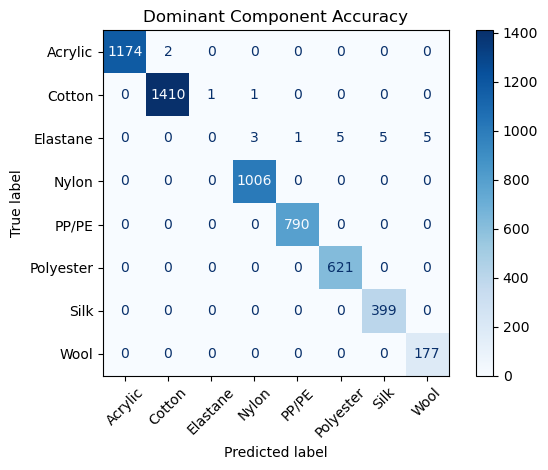

Dominant class accuracy: 0.9959


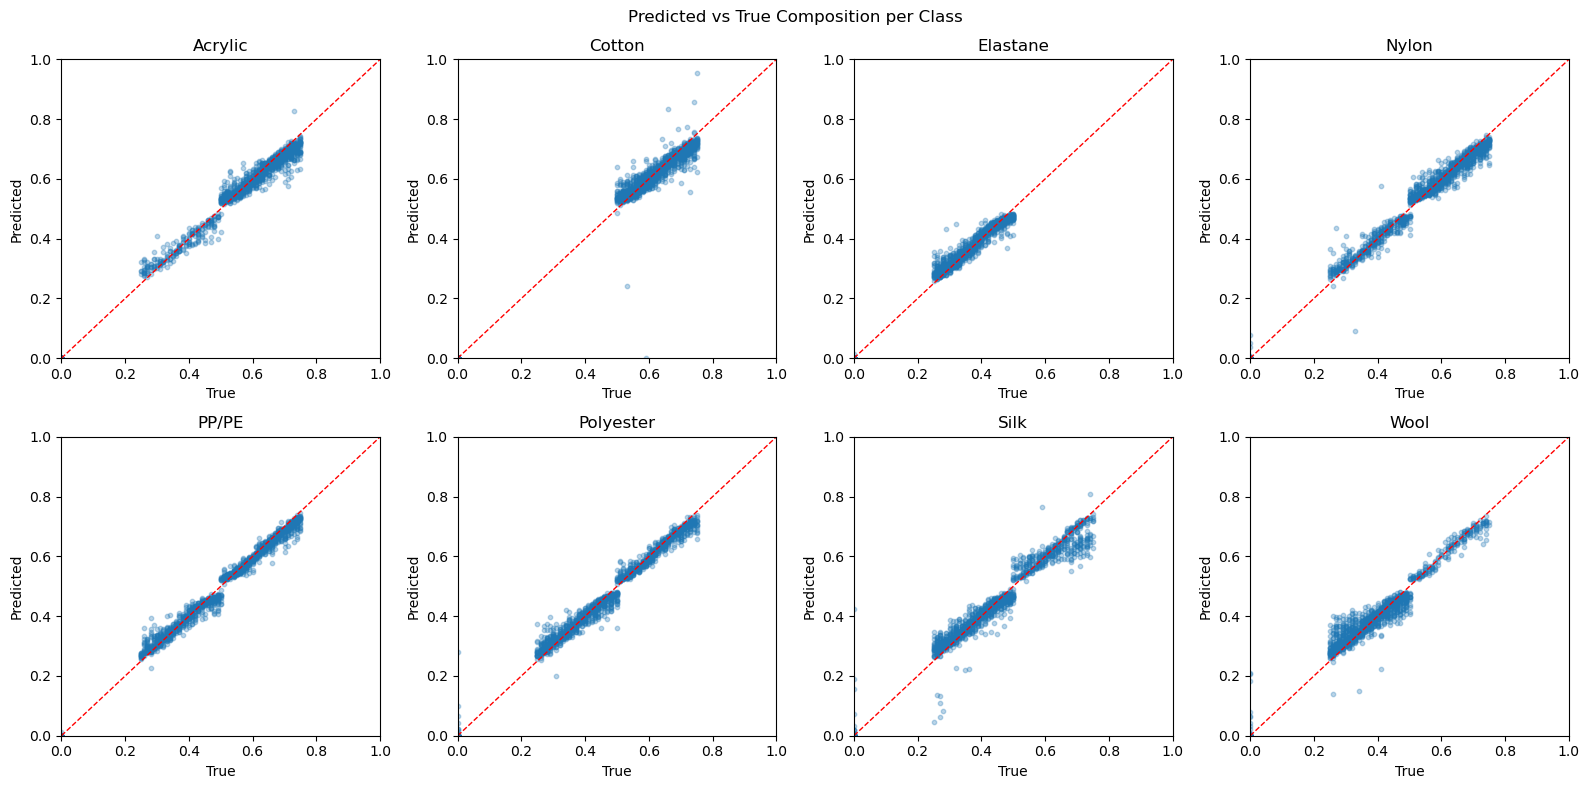

In [63]:
# Recreate val_loader
X_tr, X_val, y_tr, y_val = train_test_split(
    X_mix, y_mix, test_size=0.2, random_state=57
)

def to_tensor(X, y):
    return (torch.tensor(X[:, None, :], dtype=torch.float32),
            torch.tensor(y,             dtype=torch.float32))

X_val_t, y_val_t = to_tensor(X_val, y_val)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)

model.eval()
val_preds, val_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        val_preds.append(model(xb).numpy())
        val_true.append(yb.numpy())

val_preds = np.vstack(val_preds) 
val_true  = np.vstack(val_true) 

print(f"{'Class':<12} {'MAE':>8} {'R²':>8}")
print("-" * 30)
for i, cls in enumerate(classes):
    mae = mean_absolute_error(val_true[:, i], val_preds[:, i])
    r2  = r2_score(val_true[:, i], val_preds[:, i])
    print(f"{cls:<12} {mae:>8.4f} {r2:>8.4f}")

overall_mae = mean_absolute_error(val_true, val_preds)
print(f"\nOverall MAE: {overall_mae:.4f}")


# Mean absolute error across all components per sample
per_sample_error = np.abs(val_true - val_preds).sum(axis=1) / 2
print(f"Mean composition error: {per_sample_error.mean():.4f}")
print(f"Median:                 {np.median(per_sample_error):.4f}")
print(f"90th percentile:        {np.percentile(per_sample_error, 90):.4f}")


# Check if the predicted dominant class matches the true dominant class
true_dominant = np.argmax(val_true,  axis=1)
pred_dominant = np.argmax(val_preds, axis=1)


cm   = confusion_matrix(true_dominant, pred_dominant)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Dominant Component Accuracy")
plt.tight_layout()
plt.show()

dominant_acc = (true_dominant == pred_dominant).mean()
print(f"Dominant class accuracy: {dominant_acc:.4f}")


fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, cls in enumerate(classes):
    ax = axes[i]
    ax.scatter(val_true[:, i], val_preds[:, i], alpha=0.3, s=10)
    ax.plot([0, 1], [0, 1], 'r--', lw=1)   # perfect prediction line
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(cls)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle("Predicted vs True Composition per Class")
plt.tight_layout()
plt.show()

In [ ]:
#  Testing
wn_common = np.arange(3999.0, 674.0, -1)

spectral_cols = [str(x) for x in wn_common]

def load_and_interpolate_csv(filepath):
    df = pd.read_csv(filepath, header=None)
    
    wn_src = df.iloc[:, 0].values
    ab_src = df.iloc[:, 1].values
    
    sort_idx = np.argsort(wn_src)
    wn_src = wn_src[sort_idx]
    ab_src = ab_src[sort_idx]
    
    f_interp = interp1d(wn_src, ab_src,
                        kind='cubic',
                        bounds_error=False,
                        fill_value=np.nan)
    
    interpolated = f_interp(wn_common)
    
    if np.any(np.isnan(interpolated)):
        nans = np.isnan(interpolated)
        interpolated[nans] = np.interp(
            np.where(nans)[0],
            np.where(~nans)[0],
            interpolated[~nans]
        )
    
    return interpolated


folder = Path("Lab_Mixes")

rows = []
    
for csv_file in folder.glob("*.csv"):
    spectrum = load_and_interpolate_csv(csv_file)
    
    name = csv_file.stem

    spectrum_id = name.rsplit("_", 1)[1]
    label       = name.rsplit("_", 1)[0]    

    # if "Nylon" in label:
    #     continue
    
    row = {'Spectrum_ID': spectrum_id, 'Labels': label}
    row.update(dict(zip(spectral_cols, spectrum)))
    rows.append(row)

df_test_mix = pd.DataFrame(rows)
df_test_mix.head(50)

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,1,Polyester_0.56_Silk_0.44,101.226853,101.276511,101.145734,101.293992,101.168725,101.131059,101.213614,101.132464,...,74.348121,74.646014,74.307265,74.443139,74.539186,74.607498,74.560003,74.444949,74.486754,74.640241
1,2,Polyester_0.56_Silk_0.44,99.674056,99.653431,99.596815,99.586962,99.675460,99.706584,99.640596,99.631850,...,70.161988,70.023646,70.127770,69.952335,70.288181,70.321345,70.290311,70.280636,70.176685,70.353664
2,3,Polyester_0.56_Silk_0.44,97.119619,97.109088,97.065428,97.070678,97.126412,97.055732,97.125776,97.076464,...,72.610906,72.788421,72.963470,72.423692,72.706064,72.868167,73.012326,72.883794,72.680246,72.748364
3,6,Polyester_0.56_Silk_0.44,100.788347,100.820122,100.809312,100.700098,100.589128,100.643461,100.855138,100.831187,...,67.356080,67.372151,67.238374,67.045876,66.994961,67.120807,67.120487,66.929060,67.026293,67.279211
4,4,Polyester_0.56_Silk_0.44,100.879774,100.997754,101.043304,100.910213,100.790116,100.888748,101.157622,101.130506,...,68.200433,68.645003,68.430023,67.840089,67.671057,68.062983,68.325337,68.068480,67.944281,68.183357
5,5,Polyester_0.56_Silk_0.44,101.259044,101.456892,101.499967,101.234758,101.035351,101.165100,101.514687,101.574749,...,67.994067,67.842617,67.647642,67.526386,67.590803,67.775478,67.739719,67.440201,67.416478,67.580805
6,8,Polyester_0.70_Cotton_0.30,95.902365,95.972406,95.970461,95.802643,95.727055,95.883562,96.132052,96.090132,...,75.783511,75.673731,75.828623,75.989828,75.918356,75.930846,76.116159,76.403281,76.719041,76.930620
7,5,Cotton_0.95_Elastane_0.05,99.840361,99.962847,100.040988,99.920001,99.809605,99.897053,100.111773,100.043447,...,62.262724,61.765991,61.534885,61.619027,61.494486,60.885580,60.274701,59.989361,59.547210,58.800504
8,4,Cotton_0.95_Elastane_0.05,99.626139,99.743707,99.743947,99.534413,99.433773,99.605573,99.884609,99.838349,...,61.079104,60.974998,60.784377,60.404219,59.883772,59.515693,59.127343,58.491547,57.753191,57.203691
9,9,Polyester_0.70_Cotton_0.30,96.182020,96.231005,96.127703,95.899772,95.905414,96.162262,96.366528,96.226854,...,72.159009,72.455512,72.606483,72.584382,72.691794,73.044471,73.271016,73.283555,73.696260,74.281263


In [58]:
L = df_test_mix.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected_test = df_test_mix.copy()

for i in range(df_test_mix.shape[0]):
    y = df_test_mix.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected_test.iloc[i, 2:] = y - baseline

meta_test = corrected_test.iloc[:, :2].reset_index(drop=True)
values_test = corrected_test.iloc[:, 2:].astype(float)
    
normalized_test = values_test.copy()

for i in range(values_test.shape[0]):
    row = values_test.iloc[i].values
    normalized_test.iloc[i, :] = (row - row.mean())/row.std()

smoothed_test = normalized_test.copy()

for i in range(normalized_test.shape[0]):
    smoothed_test.iloc[i, :] = savgol_filter(normalized_test.iloc[i, :], window_length=9, polyorder=3)

final_df_test_mix = pd.concat([meta_test, smoothed_test], axis=1)

final_df_test_mix.iloc[:, :].head(20)

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,1,Polyester_0.56_Silk_0.44,-0.661645,-0.655028,-0.656048,-0.661531,-0.668302,-0.670684,-0.662322,-0.663062,...,-0.331255,-0.273602,-0.208707,-0.128850,-0.070263,-0.023932,0.041357,0.106660,0.169219,0.226275
1,2,Polyester_0.56_Silk_0.44,-0.635302,-0.645443,-0.648627,-0.646716,-0.641571,-0.635387,-0.629810,-0.625689,...,-0.329505,-0.278714,-0.210808,-0.133218,-0.062402,0.007608,0.072765,0.134190,0.191868,0.245784
2,3,Polyester_0.56_Silk_0.44,-0.632838,-0.639522,-0.642256,-0.641917,-0.639377,-0.636865,-0.628536,-0.625339,...,-0.318540,-0.309853,-0.274808,-0.202999,-0.118533,-0.063003,0.015522,0.078631,0.112878,0.104817
3,6,Polyester_0.56_Silk_0.44,-0.642191,-0.664615,-0.675991,-0.679142,-0.676890,-0.675230,-0.678307,-0.672662,...,-0.306377,-0.243329,-0.206069,-0.169495,-0.135179,-0.098571,-0.043491,0.022242,0.099452,0.188966
4,4,Polyester_0.56_Silk_0.44,-0.661599,-0.673499,-0.674259,-0.667689,-0.657597,-0.649843,-0.655052,-0.660713,...,-0.384634,-0.319887,-0.264656,-0.217019,-0.190008,-0.163970,-0.077471,0.007437,0.072824,0.100759
5,5,Polyester_0.56_Silk_0.44,-0.626021,-0.634057,-0.642279,-0.648564,-0.650791,-0.644477,-0.633581,-0.613741,...,-0.385343,-0.341997,-0.314727,-0.274120,-0.225970,-0.178383,-0.123665,-0.071384,-0.024892,0.012461
6,8,Polyester_0.70_Cotton_0.30,-0.593320,-0.609862,-0.615593,-0.613386,-0.606113,-0.600583,-0.594983,-0.583488,...,3.565494,3.601395,3.620651,3.647985,3.691542,3.742567,3.793989,3.856136,3.932741,4.027538
7,5,Cotton_0.95_Elastane_0.05,-0.754586,-0.753136,-0.748671,-0.742765,-0.736991,-0.737175,-0.743589,-0.740230,...,0.171464,0.208134,0.234205,0.230728,0.220374,0.211386,0.160264,0.094388,0.019667,-0.057992
8,4,Cotton_0.95_Elastane_0.05,-0.699397,-0.723169,-0.732164,-0.730386,-0.721840,-0.715865,-0.711404,-0.700862,...,0.266873,0.296600,0.299305,0.286655,0.258602,0.204788,0.142537,0.066220,-0.024044,-0.128135
9,9,Polyester_0.70_Cotton_0.30,-0.576390,-0.602754,-0.612247,-0.609933,-0.600876,-0.596832,-0.592149,-0.585381,...,3.560767,3.606025,3.647242,3.695324,3.740913,3.783733,3.837209,3.899792,3.973895,4.061929


In [59]:
X_lab = final_df_test_mix.iloc[:, 2:].to_numpy(dtype=np.float32)

model.eval()
with torch.no_grad():
    x     = torch.tensor(X_lab[:, None, :], dtype=torch.float32)
    preds = model(x).numpy()  # (n_samples, n_classes)


results = pd.DataFrame(preds, columns=classes)
results.insert(0, "Spectrum_ID", final_df_test_mix["Spectrum_ID"].values)
results.insert(1, "True_Label",  final_df_test_mix["Labels"].values)

results[classes] = (results[classes] * 100).round(1)
print(results.to_string(index=False))

Spectrum_ID                 True_Label  Acrylic    Cotton  Elastane  PP/PE  Polyester      Silk      Wool
          1   Polyester_0.56_Silk_0.44      0.0  0.200000  0.700000    0.0   0.000000 70.199997 28.700001
          2   Polyester_0.56_Silk_0.44      0.0  0.200000  0.700000    0.0   0.000000 72.599998 26.400000
          3   Polyester_0.56_Silk_0.44      0.0  0.000000  0.000000    0.0   0.000000 62.700001 37.299999
          6   Polyester_0.56_Silk_0.44      0.0  0.000000  0.200000    0.0   0.100000 67.500000 32.200001
          4   Polyester_0.56_Silk_0.44      0.0  0.000000  0.100000    0.0   0.200000 65.800003 33.799999
          5   Polyester_0.56_Silk_0.44      0.0  0.000000  0.200000    0.0   0.100000 67.599998 32.099998
          8 Polyester_0.70_Cotton_0.30      0.0  0.000000  0.300000    0.0  95.800003  2.500000  1.400000
          5  Cotton_0.95_Elastane_0.05      0.0 77.500000 18.500000    0.0   0.100000  3.300000  0.600000
          4  Cotton_0.95_Elastane_0.05      0.

In [60]:
y_true_lab = np.array([
    parse_composition(lbl, classes)
    for lbl in final_df_test_mix["Labels"]
], dtype=np.float32)

mae = mean_absolute_error(y_true_lab, preds)
print(f"\nOverall MAE on lab data: {mae:.4f}")

for i, cls in enumerate(classes):
    if y_true_lab[:, i].sum() > 0:  # only show classes that appear
        print(f"  {cls:<12}: {mean_absolute_error(y_true_lab[:, i], preds[:, i]):.4f}")


Overall MAE on lab data: 0.1003
  Acrylic     : 0.0471
  Cotton      : 0.1094
  Elastane    : 0.0259
  Polyester   : 0.1809
  Silk        : 0.1301
  Wool        : 0.2087


Dominant class accuracy: 51.43%


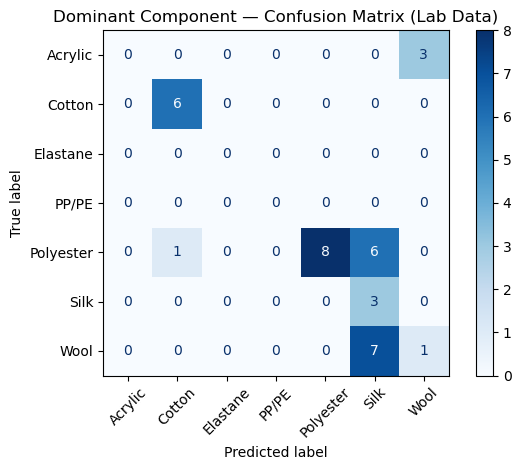

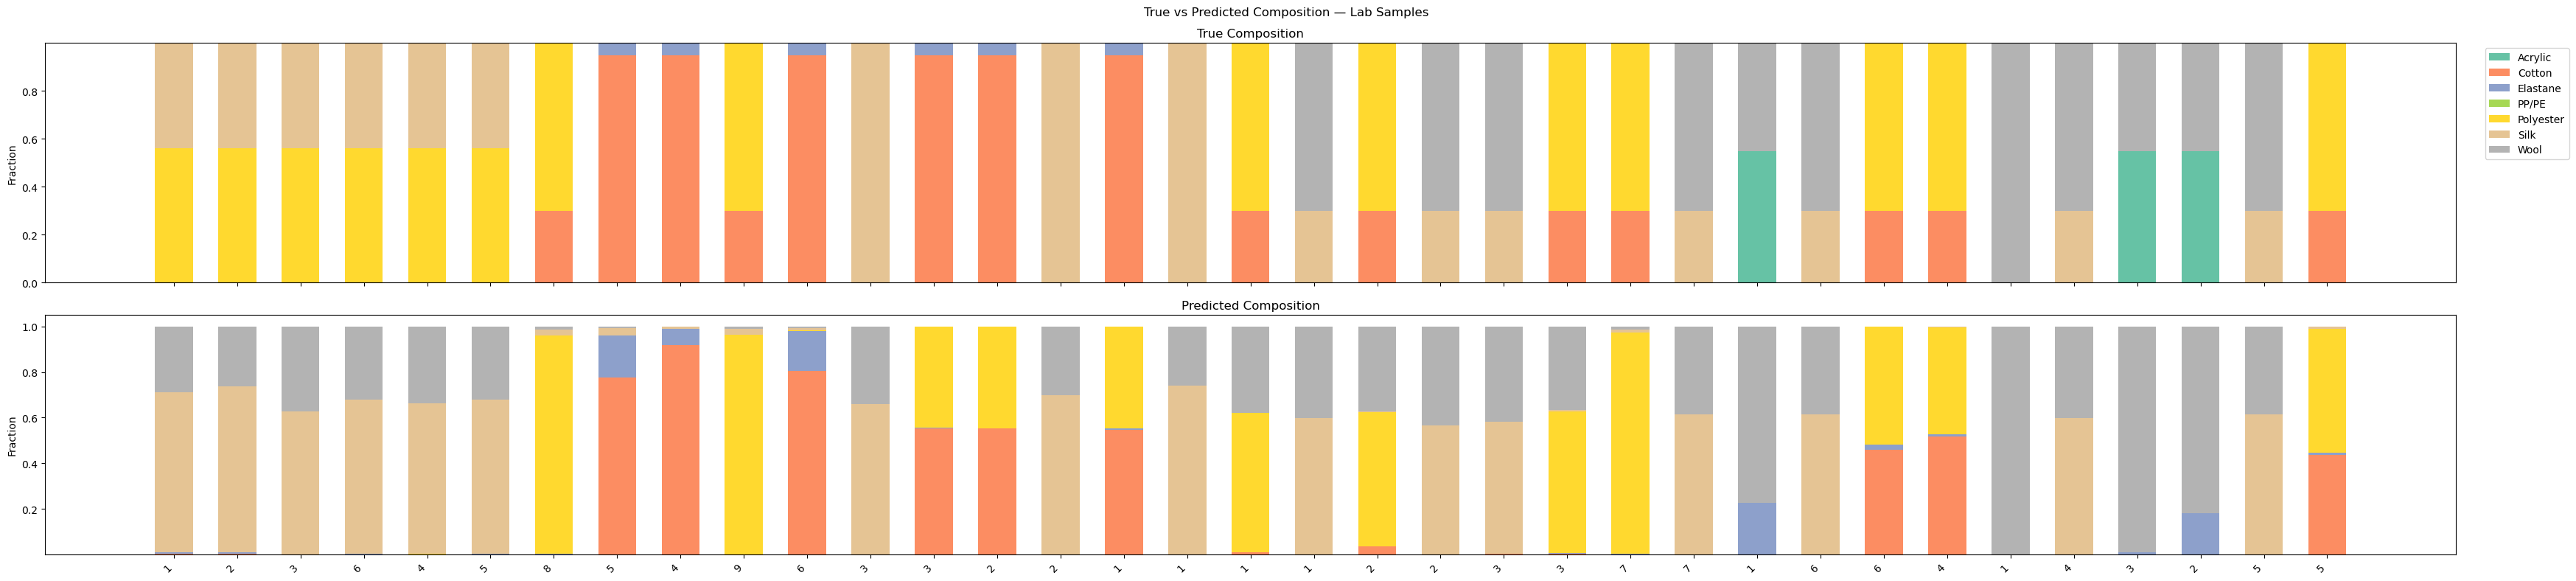

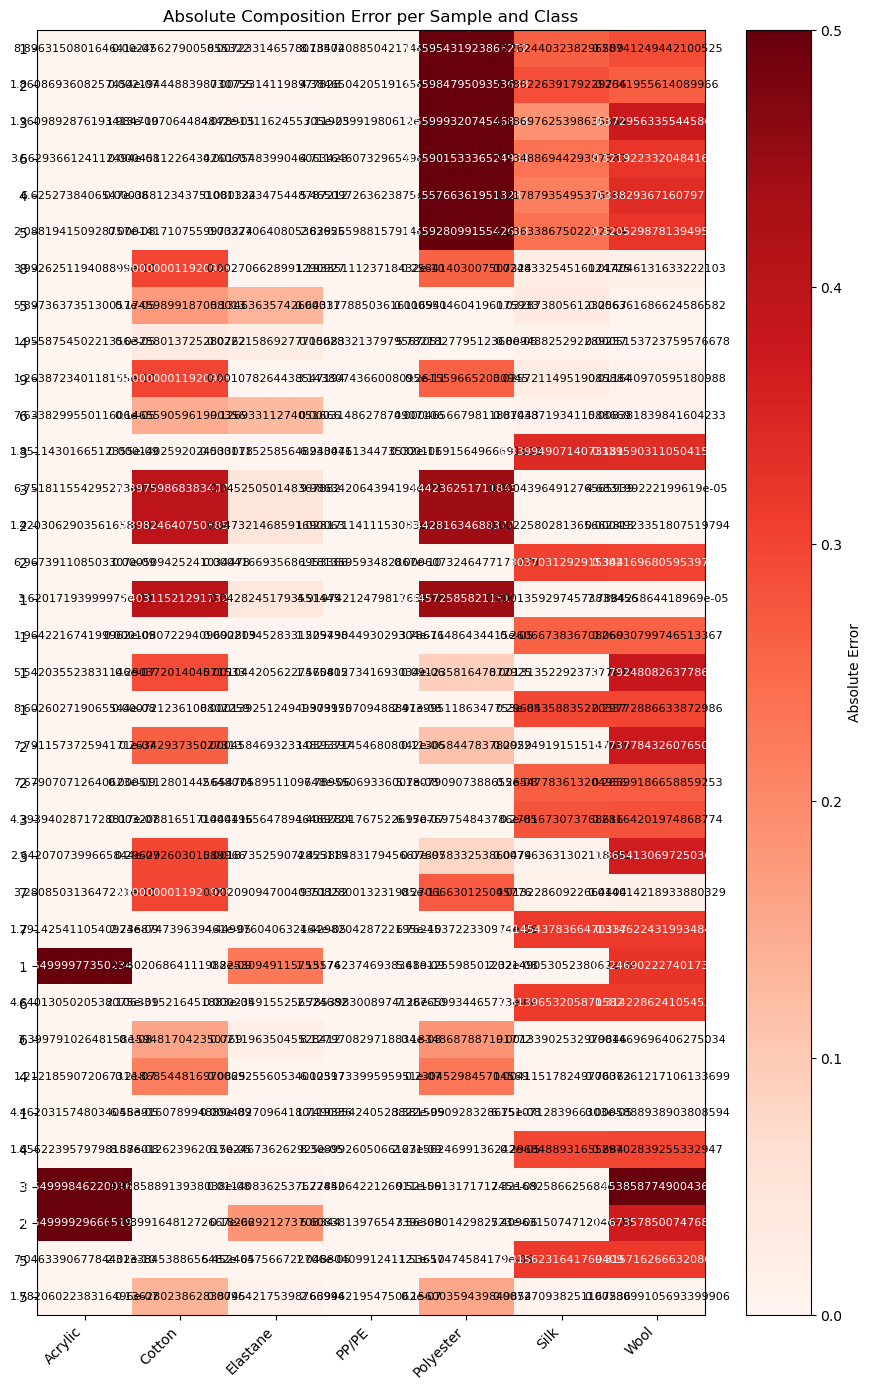

In [61]:
true_dominant = np.argmax(y_true_lab, axis=1)
pred_dominant = np.argmax(preds,      axis=1)

dominant_acc = (true_dominant == pred_dominant).mean()
print(f"Dominant class accuracy: {dominant_acc:.2%}")

cm   = confusion_matrix(true_dominant, pred_dominant, labels=range(len(classes)))
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Dominant Component — Confusion Matrix (Lab Data)")
plt.tight_layout()
plt.show()

# Predicted vs True composition per sample
n_samples = len(preds)
x_pos     = np.arange(n_samples)
width     = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(max(10, n_samples), 8), sharex=True)

bottom_true = np.zeros(n_samples)
bottom_pred = np.zeros(n_samples)

colors = plt.cm.Set2(np.linspace(0, 1, len(classes)))

for i, (cls, color) in enumerate(zip(classes, colors)):
    ax1.bar(x_pos, y_true_lab[:, i], bottom=bottom_true,
            label=cls, color=color, width=0.6)
    ax2.bar(x_pos, preds[:, i],      bottom=bottom_pred,
            label=cls, color=color, width=0.6)
    bottom_true += y_true_lab[:, i]
    bottom_pred += preds[:, i]

ax1.set_title("True Composition")
ax2.set_title("Predicted Composition")
ax1.set_ylabel("Fraction")
ax2.set_ylabel("Fraction")
ax2.set_xticks(x_pos)
ax2.set_xticklabels(final_df_test_mix["Spectrum_ID"].values, rotation=45, ha="right")
ax1.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("True vs Predicted Composition — Lab Samples")
plt.tight_layout()
plt.show()

# Error heatmap — how wrong per class per sample
error_matrix = np.abs(y_true_lab - preds)  # (n_samples, n_classes)

fig, ax = plt.subplots(figsize=(len(classes) + 2, max(4, n_samples * 0.4)))
im = ax.imshow(error_matrix, cmap="Reds", aspect="auto", vmin=0, vmax=0.5)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(n_samples))
ax.set_yticklabels(final_df_test_mix["Spectrum_ID"].values)
plt.colorbar(im, ax=ax, label="Absolute Error")

# Annotate cells with error values
for i in range(n_samples):
    for j in range(len(classes)):
        ax.text(j, i, f"{error_matrix[i, j]}",
                ha="center", va="center", fontsize=8,
                color="black" if error_matrix[i, j] < 0.3 else "white")

ax.set_title("Absolute Composition Error per Sample and Class")
plt.tight_layout()
plt.show()

In [13]:
class UMAPTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=30, n_neighbors=10, min_dist=0.1, random_state=57, supervised=False):
        self.n_components = n_components
        self.n_neighbors  = n_neighbors
        self.min_dist     = min_dist
        self.random_state = random_state
        self.supervised   = supervised

    def fit(self, X, y=None):
        self.umap_ = umap.UMAP(
            n_components=self.n_components,
            n_neighbors=self.n_neighbors,
            min_dist=self.min_dist,
            random_state=self.random_state
        )
        if self.supervised:
            y = LabelEncoder().fit_transform(y)
            self.umap_.fit(X, y=y) # supervised
        else:
            self.umap_.fit(X)      # unsupervised
        return self

    def transform(self, X):
        return self.umap_.transform(X)

In [14]:
pca_full = PCA()
pca_full.fit(synthetic_pure_df.iloc[:, 2:].values)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95%, 99% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(n_components_95)
print(n_components_99)

13
26


(9684, 13)


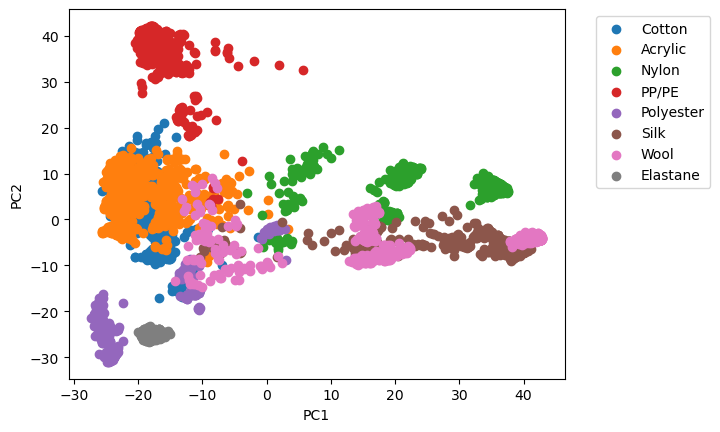

In [17]:
labels = synthetic_pure_df["Labels"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=13)
pca_data = pca.fit_transform(synthetic_pure_df.iloc[:, 2:].values)
print(pca_data.shape)

for lab in uniques:
    idx = labels == lab
    plt.scatter(pca_data[idx, 0], pca_data[idx, 1], label=lab)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10], "gamma": [0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, "scale"], "kernel": ["rbf"]}

svm = SVC()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

grid = GridSearchCV(estimator=svm, param_grid=param_grid, cv=skf, scoring="accuracy")
grid.fit(pca_data, labels)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'C': 5, 'gamma': 0.0005, 'kernel': 'rbf'}
Best CV accuracy: 0.9997934950955084


PCA+SVM:  0.999586990191017 ± 0.0005058316453862951


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

UMAP_SUP+SVM: 0.994217489344091 ± 0.0015789463873859908


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for p

UMAP_UN+SVM: 0.9881246346697841 ± 0.00259214850846149


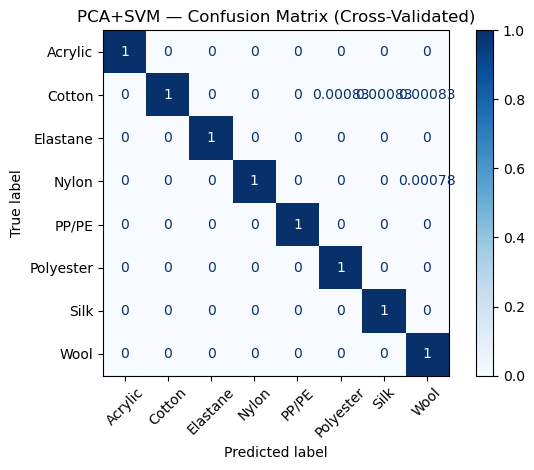


PCA+SVM Classification Report:

              precision    recall  f1-score   support

     Acrylic       1.00      1.00      1.00      1176
      Cotton       1.00      1.00      1.00      1205
    Elastane       1.00      1.00      1.00      1031
       Nylon       1.00      1.00      1.00      1277
       PP/PE       1.00      1.00      1.00      1411
   Polyester       1.00      1.00      1.00      1185
        Silk       1.00      1.00      1.00      1203
        Wool       1.00      1.00      1.00      1196

    accuracy                           1.00      9684
   macro avg       1.00      1.00      1.00      9684
weighted avg       1.00      1.00      1.00      9684



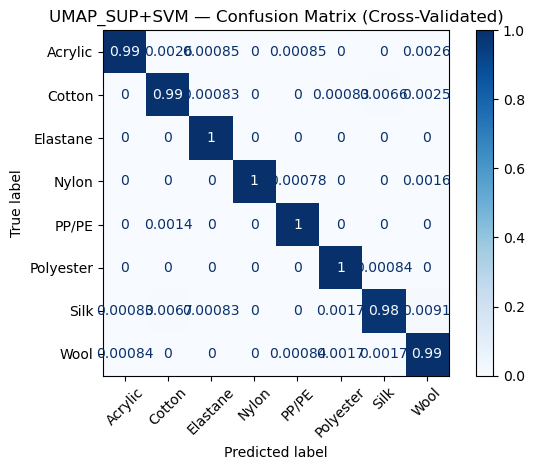


UMAP_SUP+SVM Classification Report:

              precision    recall  f1-score   support

     Acrylic       1.00      0.99      1.00      1176
      Cotton       0.99      0.99      0.99      1205
    Elastane       1.00      1.00      1.00      1031
       Nylon       1.00      1.00      1.00      1277
       PP/PE       1.00      1.00      1.00      1411
   Polyester       1.00      1.00      1.00      1185
        Silk       0.99      0.98      0.99      1203
        Wool       0.98      0.99      0.99      1196

    accuracy                           0.99      9684
   macro avg       0.99      0.99      0.99      9684
weighted avg       0.99      0.99      0.99      9684



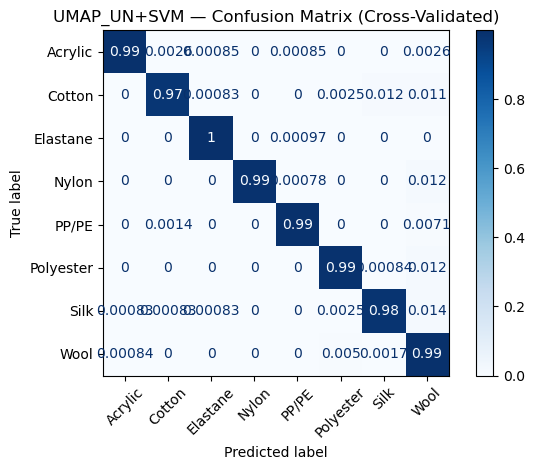


UMAP_UN+SVM Classification Report:

              precision    recall  f1-score   support

     Acrylic       1.00      0.99      1.00      1176
      Cotton       0.99      0.97      0.98      1205
    Elastane       1.00      1.00      1.00      1031
       Nylon       1.00      0.99      0.99      1277
       PP/PE       1.00      0.99      0.99      1411
   Polyester       0.99      0.99      0.99      1185
        Silk       0.99      0.98      0.98      1203
        Wool       0.94      0.99      0.97      1196

    accuracy                           0.99      9684
   macro avg       0.99      0.99      0.99      9684
weighted avg       0.99      0.99      0.99      9684



In [20]:
X      = synthetic_pure_df.iloc[:, 2:].to_numpy(dtype=np.float32)
labels = synthetic_pure_df["Labels"]
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

# PCA + SVM pipeline
pca_svm = Pipeline([
    ("pca", PCA(n_components=13)),
    ("svm", SVC(kernel="rbf", C=5, gamma=0.0005))
])

pca_scores = cross_val_score(pca_svm, X, labels, cv=skf, scoring="accuracy")
pca_pred   = cross_val_predict(pca_svm, X, labels, cv=skf)
print(f"PCA+SVM:  {pca_scores.mean()} ± {pca_scores.std()}")


# UMAP (supervised) + SVM pipeline
umap_sup_svm = Pipeline([
    ("umap", UMAPTransformer(n_components=30, n_neighbors=10, min_dist=0.1, supervised=True)),
    ("svm",  SVC(kernel="rbf", C=5, gamma=0.0005))
])

umap_sup_scores = cross_val_score(umap_sup_svm, X, labels, cv=skf, scoring="accuracy")
umap_sup_pred   = cross_val_predict(umap_sup_svm, X, labels, cv=skf)
print(f"UMAP_SUP+SVM: {umap_sup_scores.mean()} ± {umap_sup_scores.std()}")

# UMAP (unsupervised) + SVM pipeline
umap_un_svm = Pipeline([
    ("umap", UMAPTransformer(n_components=30, n_neighbors=10, min_dist=0.1, supervised=False)),
    ("svm",  SVC(kernel="rbf", C=5, gamma=0.0005))
])

umap_un_scores = cross_val_score(umap_un_svm, X, labels, cv=skf, scoring="accuracy")
umap_un_pred   = cross_val_predict(umap_un_svm, X, labels, cv=skf)
print(f"UMAP_UN+SVM: {umap_un_scores.mean()} ± {umap_un_scores.std()}")


# Confusion matrices
for name, pred in [("PCA+SVM", pca_pred), ("UMAP_SUP+SVM", umap_sup_pred), ("UMAP_UN+SVM", umap_un_pred)]:
    cm   = confusion_matrix(labels, pred, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(labels))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (Cross-Validated)")
    plt.tight_layout()
    plt.show()
    print(f"\n{name} Classification Report:\n")
    print(classification_report(labels, pred))

In [21]:
#  Testing
wn_common = np.arange(3999.0, 674.0, -1)

spectral_cols = [str(x) for x in wn_common]

def load_and_interpolate_csv(filepath):
    df = pd.read_csv(filepath, header=None)
    
    wn_src = df.iloc[:, 0].values
    ab_src = df.iloc[:, 1].values
    
    sort_idx = np.argsort(wn_src)
    wn_src = wn_src[sort_idx]
    ab_src = ab_src[sort_idx]
    
    f_interp = interp1d(wn_src, ab_src,
                        kind='cubic',
                        bounds_error=False,
                        fill_value=np.nan)
    
    interpolated = f_interp(wn_common)
    
    if np.any(np.isnan(interpolated)):
        nans = np.isnan(interpolated)
        interpolated[nans] = np.interp(
            np.where(nans)[0],
            np.where(~nans)[0],
            interpolated[~nans]
        )
    
    return interpolated


folder = Path("Lab_IR")

rows = []
    
for csv_file in folder.glob("*.csv"):
    spectrum = load_and_interpolate_csv(csv_file)
    
    name = csv_file.stem

    label, spectrum_id = name.rsplit("_", 1)

    if label == "cotton":
        label = "Cotton"
    if label == "cottonshirt":
        label = "Cotton"
    if label == "polyestershirt":
        label = "Polyester"
    if label == "polyester":
        label = "Polyester"
    if label == "silk":
        label = "Silk"
    if label == "wool":
        label = "Wool"
    
    row = {'Spectrum_ID': spectrum_id, 'Labels': label}
    row.update(dict(zip(spectral_cols, spectrum)))
    rows.append(row)

df_test = pd.DataFrame(rows)
df_test.head()

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,3,Silk,97.245834,97.390115,97.293514,97.374634,97.163049,97.482733,97.237617,97.358753,...,74.666039,74.643516,74.629892,74.535143,74.461359,74.726935,74.297934,74.462056,74.377235,74.571370
1,2,Silk,98.032160,98.084969,98.174308,98.013137,97.915752,98.244996,98.066947,98.018618,...,75.655386,76.034547,75.628184,75.618355,75.521211,75.636475,75.631651,75.709878,75.658246,75.554447
2,1,Silk,94.359574,94.531836,94.514420,94.446630,94.350092,94.545224,94.394739,94.488604,...,65.209933,65.381910,65.074588,64.894939,65.003864,65.034800,64.997721,65.091411,65.086720,65.170327
3,4,Polyester,96.979594,96.957995,96.849516,96.958404,96.945043,96.899976,97.010140,96.900023,...,80.804923,81.056305,81.375346,81.190403,81.364107,81.480191,81.648514,81.887856,81.820115,82.372542
4,2,Cotton,98.144183,98.195978,98.076160,98.236818,98.040478,98.194442,98.124280,98.335664,...,79.186056,79.190918,78.886189,78.733199,78.410231,78.055234,77.701188,77.542443,76.997094,76.589282


In [22]:
L = df_test.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected_test = df_test.copy()

for i in range(df_test.shape[0]):
    y = df_test.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected_test.iloc[i, 2:] = y - baseline

meta_test = corrected_test.iloc[:, :2].reset_index(drop=True)
values_test = corrected_test.iloc[:, 2:].astype(float)
    
normalized_test = values_test.copy()

for i in range(values_test.shape[0]):
    row = values_test.iloc[i].values
    normalized_test.iloc[i, :] = (row - row.mean())/row.std()

smoothed_test = normalized_test.copy()

for i in range(normalized_test.shape[0]):
    smoothed_test.iloc[i, :] = savgol_filter(normalized_test.iloc[i, :], window_length=9, polyorder=3)

final_df_test = pd.concat([meta_test, smoothed_test], axis=1)

final_df_test.iloc[:, :].head(20)

,Spectrum_ID,Labels,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,...,684.0,683.0,682.0,681.0,680.0,679.0,678.0,677.0,676.0,675.0
0,3,Silk,-0.748278,-0.748865,-0.741198,-0.730129,-0.720509,-0.737455,-0.740967,-0.736779,...,-0.431829,-0.415533,-0.363968,-0.336931,-0.301324,-0.275407,-0.244856,-0.205050,-0.150732,-0.076646
1,2,Silk,-0.747449,-0.753027,-0.748094,-0.738170,-0.728778,-0.740989,-0.754201,-0.753704,...,-0.340682,-0.312178,-0.287873,-0.261278,-0.218697,-0.182732,-0.108319,-0.042466,-0.002141,-0.004317
2,1,Silk,-0.719661,-0.709984,-0.700919,-0.693895,-0.690345,-0.705074,-0.706837,-0.708540,...,-0.417427,-0.395806,-0.359395,-0.328287,-0.285824,-0.241533,-0.170108,-0.096758,-0.029688,0.022896
3,4,Polyester,-0.577828,-0.584630,-0.587712,-0.587910,-0.586059,-0.582731,-0.578061,-0.580328,...,3.823979,3.876566,3.927052,3.973288,4.024772,4.062126,4.110136,4.166786,4.235530,4.319824
4,2,Cotton,-0.621337,-0.630307,-0.634768,-0.634751,-0.630292,-0.618612,-0.604686,-0.598545,...,0.138859,0.134737,0.070313,-0.006496,-0.048888,-0.135197,-0.223315,-0.326537,-0.447944,-0.590619
5,3,Cotton,-0.664495,-0.644321,-0.641664,-0.649272,-0.659899,-0.653799,-0.642017,-0.643019,...,0.059526,0.082144,0.037959,-0.037064,-0.082328,-0.138899,-0.176781,-0.248995,-0.379423,-0.591951
6,5,Polyester,-0.594585,-0.591754,-0.592053,-0.594117,-0.596585,-0.598401,-0.593501,-0.587451,...,3.671842,3.716319,3.777342,3.822770,3.858532,3.900910,3.950351,4.016754,4.107237,4.228915
7,1,Cotton,-0.629391,-0.629107,-0.635590,-0.643852,-0.648905,-0.626117,-0.618450,-0.604675,...,0.101642,0.087154,0.058823,-0.006758,-0.052812,-0.120009,-0.195741,-0.287843,-0.399454,-0.533714
8,2,Polyester,-0.603600,-0.598790,-0.597943,-0.599755,-0.602925,-0.604138,-0.609046,-0.606582,...,3.595673,3.647050,3.698758,3.741172,3.783750,3.828114,3.867917,3.915680,3.977286,4.058620
9,1,Polyester,-0.580790,-0.570083,-0.565103,-0.564115,-0.565389,-0.564109,-0.566037,-0.566289,...,3.818544,3.858620,3.896308,3.923791,3.962337,4.001267,4.056320,4.116018,4.177508,4.237939


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


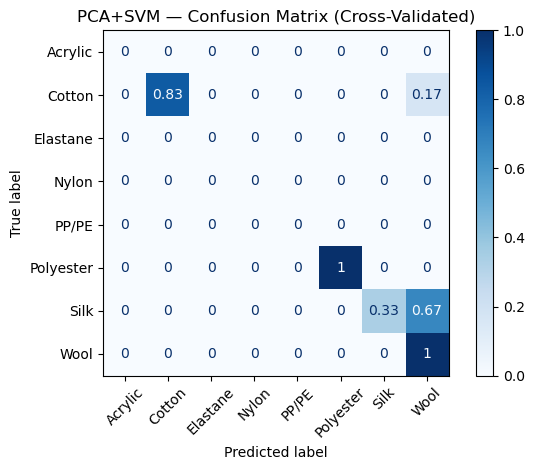


PCA+SVM Classification Report:

              precision    recall  f1-score   support

      Cotton       1.00      0.83      0.91         6
   Polyester       1.00      1.00      1.00         8
        Silk       1.00      0.33      0.50         3
        Wool       0.57      1.00      0.73         4

    accuracy                           0.86        21
   macro avg       0.89      0.79      0.78        21
weighted avg       0.92      0.86      0.85        21



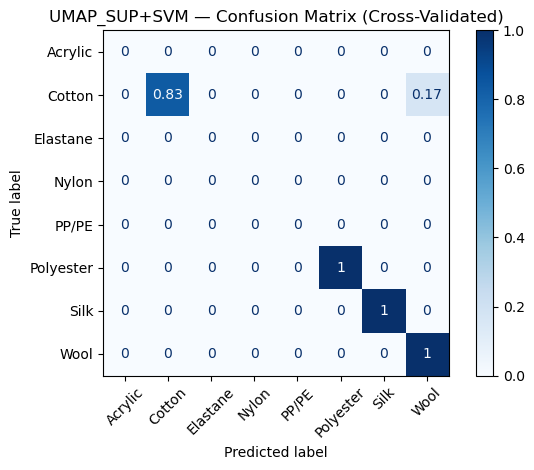


UMAP_SUP+SVM Classification Report:

              precision    recall  f1-score   support

      Cotton       1.00      0.83      0.91         6
   Polyester       1.00      1.00      1.00         8
        Silk       1.00      1.00      1.00         3
        Wool       0.80      1.00      0.89         4

    accuracy                           0.95        21
   macro avg       0.95      0.96      0.95        21
weighted avg       0.96      0.95      0.95        21



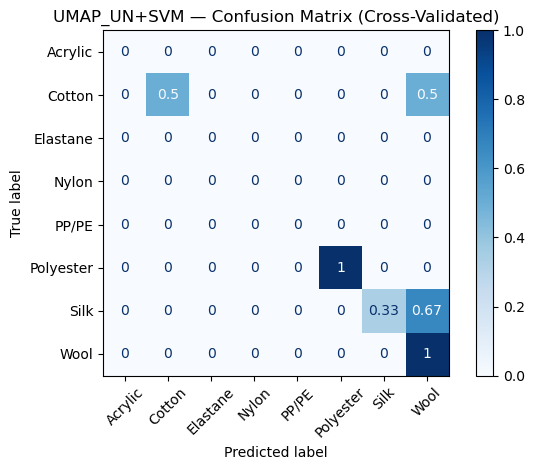


UMAP_UN+SVM Classification Report:

              precision    recall  f1-score   support

      Cotton       1.00      0.50      0.67         6
   Polyester       1.00      1.00      1.00         8
        Silk       1.00      0.33      0.50         3
        Wool       0.44      1.00      0.62         4

    accuracy                           0.76        21
   macro avg       0.86      0.71      0.70        21
weighted avg       0.89      0.76      0.76        21



,Actual,PCA_Pred,UMAP_SUP_Pred,UMAP_UN_Pred
0,Silk,Wool,Silk,Silk
1,Silk,Wool,Silk,Wool
2,Silk,Silk,Silk,Wool
3,Polyester,Polyester,Polyester,Polyester
4,Cotton,Cotton,Cotton,Cotton
5,Cotton,Cotton,Cotton,Cotton
6,Polyester,Polyester,Polyester,Polyester
7,Cotton,Cotton,Cotton,Cotton
8,Polyester,Polyester,Polyester,Polyester
9,Polyester,Polyester,Polyester,Polyester


In [23]:
labels_test = final_df_test["Labels"]

pca_svm.fit(X, labels)
umap_sup_svm.fit(X, labels)
umap_un_svm.fit(X, labels)

all_labels = pca_svm.classes_

pca_pred = pca_svm.predict(final_df_test.iloc[:, 2:])
umap_sup_pred = umap_sup_svm.predict(final_df_test.iloc[:, 2:])
umap_un_pred = umap_un_svm.predict(final_df_test.iloc[:, 2:])

# Confusion matrices
for name, pred in [("PCA+SVM", pca_pred), ("UMAP_SUP+SVM", umap_sup_pred), ("UMAP_UN+SVM", umap_un_pred)]:
    cm   = confusion_matrix(labels_test, pred, labels=all_labels, normalize="true")
    # disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(labels_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=all_labels)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{name} — Confusion Matrix (Cross-Validated)")
    plt.tight_layout()
    plt.show()
    print(f"\n{name} Classification Report:\n")
    print(classification_report(labels_test, pred))

results_df = pd.DataFrame({
    "Actual": labels_test.values,
    "PCA_Pred": pca_pred,
    "UMAP_SUP_Pred": umap_sup_pred,
    "UMAP_UN_Pred": umap_un_pred
})

results_df.head(30)

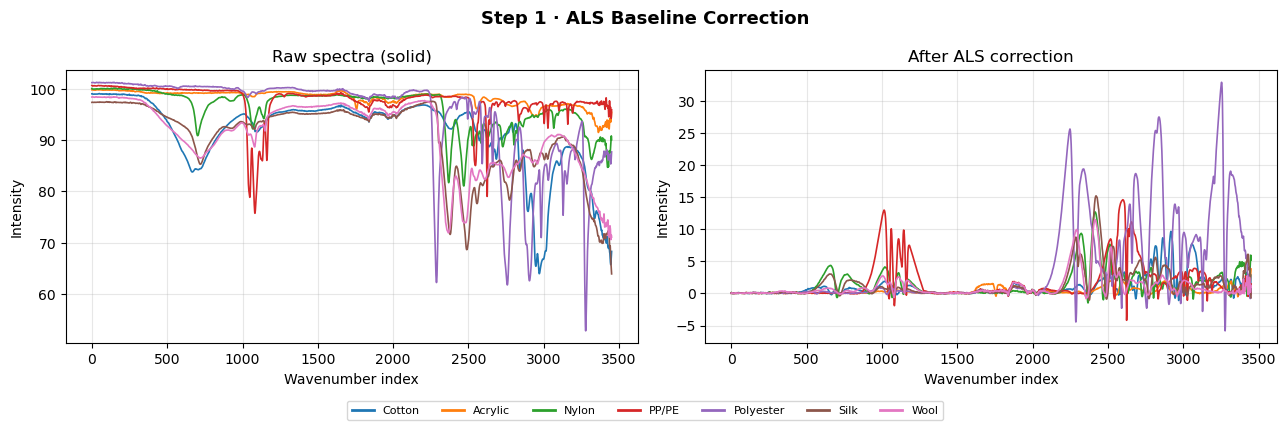

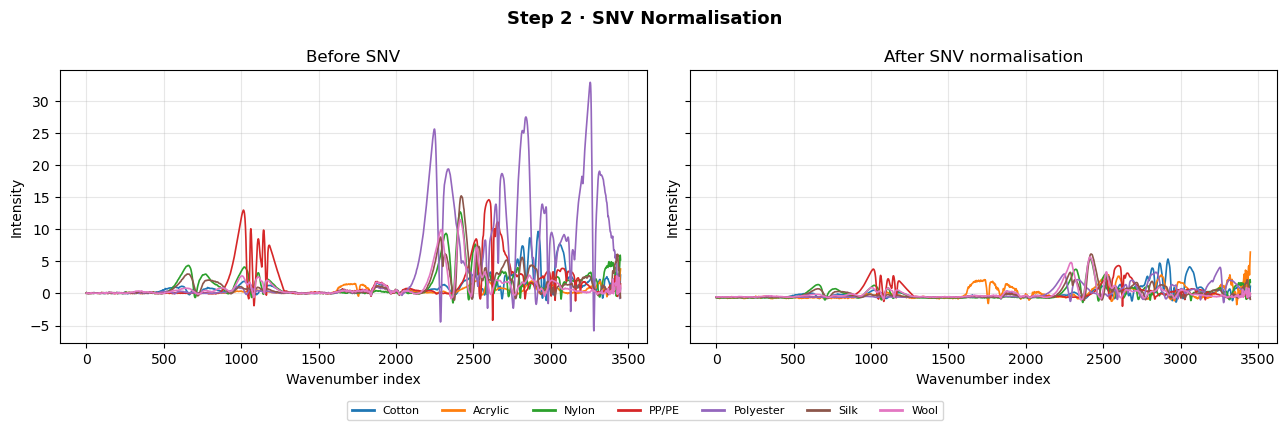

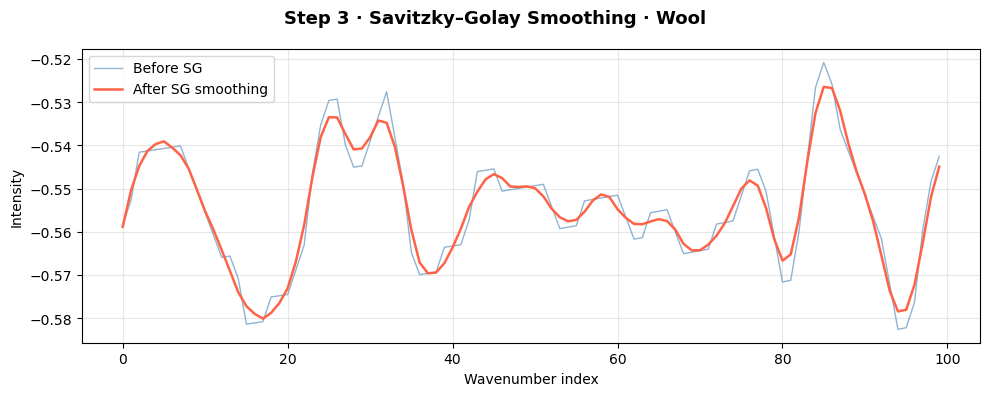

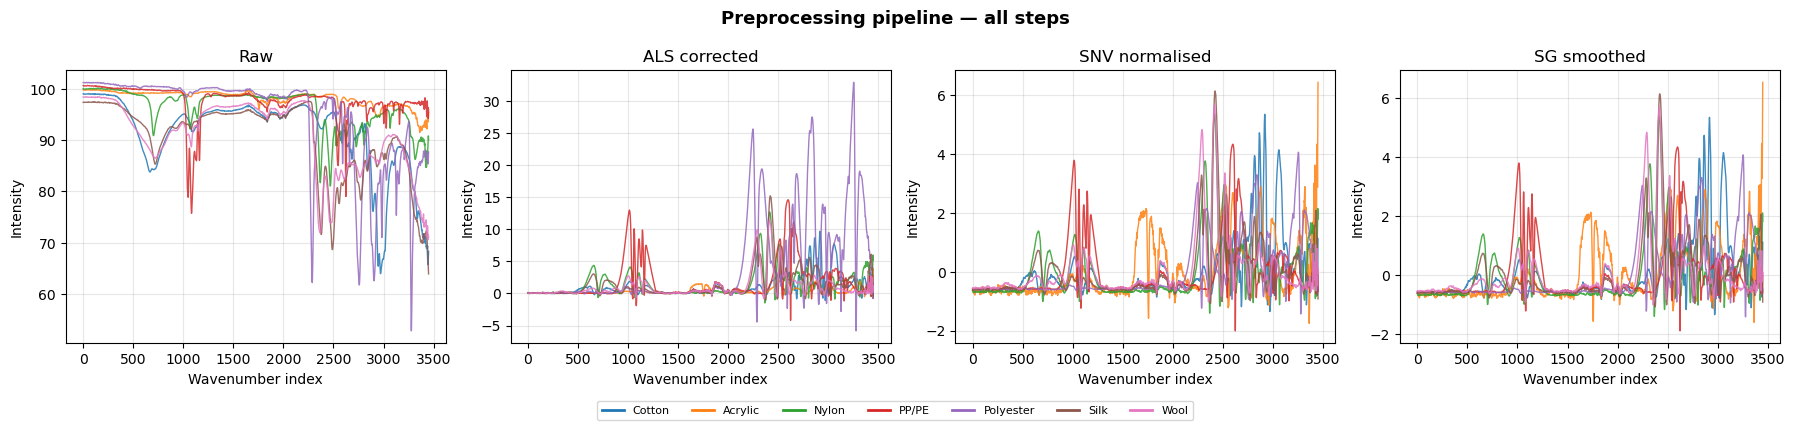

In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

plt.style.use("default")

CLASS_COLORS = {
    "Cotton":    "#1f77b4",
    "Acrylic":   "#ff7f0e",
    "Nylon":     "#2ca02c",
    "PP/PE":     "#d62728",
    "Polyester": "#9467bd",
    "Silk":      "#8c564b",
    "Wool":      "#e377c2",
}
CLASSES = list(CLASS_COLORS.keys())


rep_indices = {}
for cls in CLASSES:
    idx = spectrums_labeled[spectrums_labeled["Labels"] == cls].index[0]
    rep_indices[cls] = idx

wavenumbers = np.arange(spectrums.shape[1] - 2)

legend_handles = [Line2D([0], [0], color=CLASS_COLORS[c], lw=2, label=c) for c in CLASSES]



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle("Step 1 · ALS Baseline Correction", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    y_raw = spectrums.iloc[i, 2:].values.astype(float)
    baseline = y_raw - corrected.iloc[i, 2:].values.astype(float)
    ax1.plot(wavenumbers, y_raw,    color=c, lw=1.2, label=cls)
    ax2.plot(wavenumbers, corrected.iloc[i, 2:].values.astype(float), color=c, lw=1.2)

ax1.set_title("Raw spectra (solid)")
ax2.set_title("After ALS correction")
for ax in (ax1, ax2):
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)  
fig.suptitle("Step 2 · SNV Normalisation", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    ax1.plot(wavenumbers, corrected.iloc[i, 2:].values.astype(float),  color=c, lw=1.2, label=cls)
    ax2.plot(wavenumbers, normalized.iloc[i].values.astype(float),     color=c, lw=1.2)

ax1.set_title("Before SNV")
ax2.set_title("After SNV normalisation")
for ax in (ax1, ax2):
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()



SG_CLASS = "Wool"
i = rep_indices[SG_CLASS]
zoom = slice(0, 100) 

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f"Step 3 · Savitzky–Golay Smoothing · {SG_CLASS}",
             fontsize=13, fontweight="bold")

ax.plot(wavenumbers[zoom], normalized.iloc[i, zoom].values.astype(float),
        color="steelblue", lw=1.0, alpha=0.6, label="Before SG")
ax.plot(wavenumbers[zoom], smoothed.iloc[i, zoom].values.astype(float),
        color="tomato",    lw=1.8, label="After SG smoothing")

ax.set_xlabel("Wavenumber index")
ax.set_ylabel("Intensity")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



stage_labels = ["Raw", "ALS corrected", "SNV normalised", "SG smoothed"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle("Preprocessing pipeline — all steps", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    stages_data = [
        spectrums.iloc[i, 2:].values.astype(float),
        corrected.iloc[i, 2:].values.astype(float),
        normalized.iloc[i].values.astype(float),
        smoothed.iloc[i].values.astype(float),
    ]
    for ax, data in zip(axes, stages_data):
        ax.plot(wavenumbers, data, color=c, lw=1.0, alpha=0.85, label=cls)

for ax, title in zip(axes, stage_labels):
    ax.set_title(title)
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()